# 02 — Time-Frequency Representation Comparison

Computes and compares the four representations benchmarked in README §5.4 — mel-spectrogram, log-mel, CQT, and MFCC — on the same synthetic clip.

In [1]:
import os
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root (pyproject.toml not found)")


REPO_ROOT = _find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Working directory: {REPO_ROOT}")


Working directory: Z:\hydrosense


In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np

from src.data.synthetic import generate_synthetic_recording
from src.preprocessing.representations import (
    REPRESENTATIONS,
    compute_representation,
    expected_num_frames,
)

SAMPLE_RATE = 16000
SEGMENT_LENGTH_S = 10.0


## A 10s example clip (Class C — passenger ferry profile)

In [3]:
waveform = generate_synthetic_recording(
    "C", duration_s=SEGMENT_LENGTH_S, sample_rate=SAMPLE_RATE, seed=7
)
print(f"waveform shape: {waveform.shape}, dtype: {waveform.dtype}")


waveform shape: (160000,), dtype: float32


## Compute all four representations

| Representation | Parameters | Expected shape (README §5.4) |
|---|---|---|
| mel | n_fft=2048, hop=512, n_mels=128 | (128, 313) |
| log_mel | mel + log(1+x) | (128, 313) |
| cqt | bins/octave=24, fmin=10 Hz | (256, 313) |
| mfcc | n_mfcc=40 + Δ + ΔΔ | (120, 313) |

In [4]:
expected_frames = expected_num_frames(int(SAMPLE_RATE * SEGMENT_LENGTH_S))
print(f"expected time frames: {expected_frames}")

reps = {}
timings = {}
for name in ["mel", "log_mel", "cqt", "mfcc"]:
    start = time.perf_counter()
    reps[name] = compute_representation(waveform, SAMPLE_RATE, name)
    timings[name] = time.perf_counter() - start
    print(f"{name:10s} shape={reps[name].shape}  ({timings[name] * 1000:.1f} ms)")


expected time frames: 313


Z:\hydrosense\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mel        shape=(128, 313)  (3325.4 ms)
log_mel    shape=(128, 313)  (8.2 ms)
cqt        shape=(256, 313)  (76.3 ms)
mfcc       shape=(120, 313)  (32.0 ms)


## Visual comparison

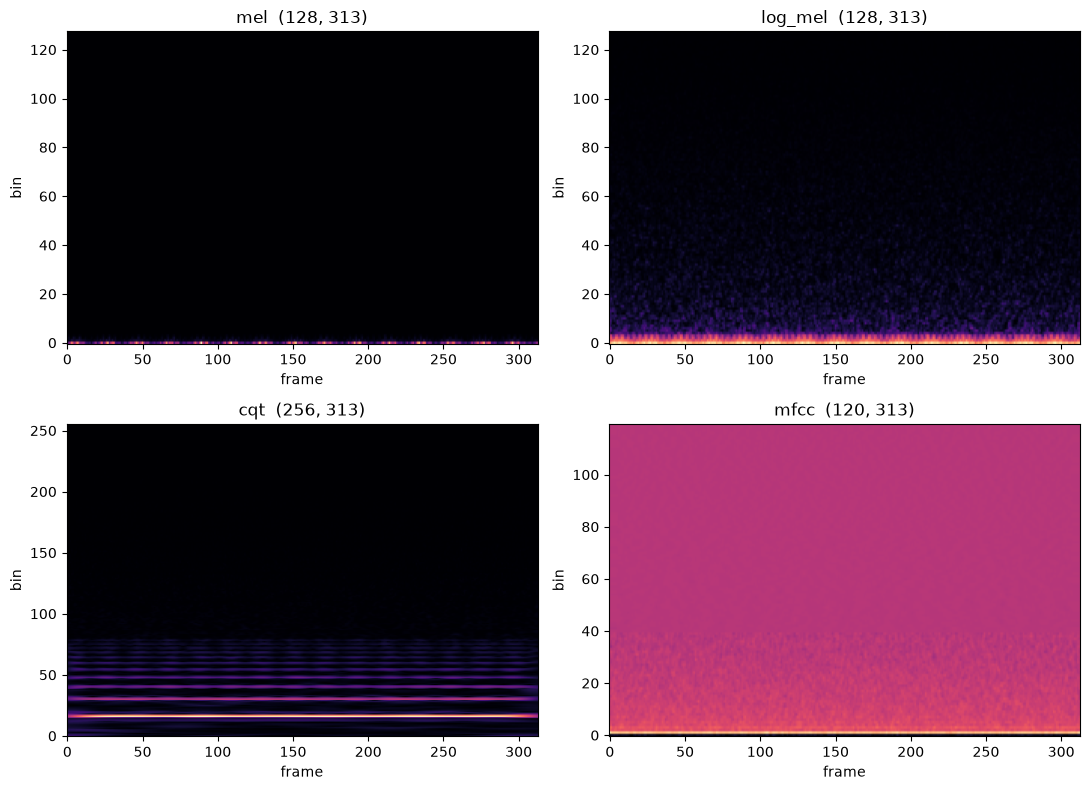

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (name, rep) in zip(axes.flat, reps.items()):
    ax.imshow(rep, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"{name}  {rep.shape}")
    ax.set_xlabel("frame")
    ax.set_ylabel("bin")
fig.tight_layout()
plt.show()


## Compute-time comparison

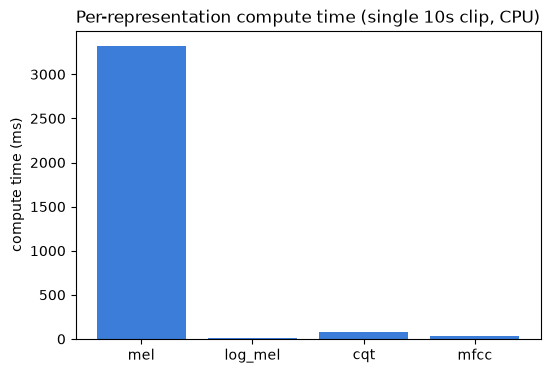

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(list(timings.keys()), [t * 1000 for t in timings.values()], color="#3b7dd8")
ax.set_ylabel("compute time (ms)")
ax.set_title("Per-representation compute time (single 10s clip, CPU)")
plt.show()


## Observations

- **Mel / log-mel** share a shape and are the cheapest to compute — log-mel is the primary representation used for training (README §5.4).
- **CQT** has double the frequency resolution (256 vs. 128 bins) and is the most expensive, reflecting its constant-Q filterbank construction.
- **MFCC** (40 coefficients + Δ + ΔΔ = 120 rows) is the most compact representation but discards the fine spectral detail Grad-CAM relies on (README §11.1), which is why it is used only for ablation, not as the primary representation.